### Check that the tracking and processing works

In [1]:
import os
if os.getcwd().endswith("notebooks"):
    os.chdir("../")

from src.tracking.tracker import MediapipeHandTracker
from src.tracking.preprocessing import TrajectoryProcessor
from src.tracking.visualization import draw_hands, draw_hand_trajectories, compare_trajectories

In [2]:
tracker = MediapipeHandTracker(target_fps=10)
processor = TrajectoryProcessor(fps=10)

In [3]:
video_path = "data/videos/Study1_Videos/2024-01-15_13-37-36.mp4"
df = tracker.track_video(video_path, overwrite=False)


⏭️ Skipping 2024-01-15_13-37-36 (already processed)


In [4]:
df_processed = processor.process(df)

In [6]:
import pandas as pd
df_processed_old = pd.read_pickle("data/processed/hand_tracking_2024-01-15_13-37-36_10fps_processed.pkl")
df_processed_old

,frame,hand_label,hand_score,bbox_center,palm_center,landmarks,frame_diff,segment_id,cx_smooth,cy_smooth,disp,disp_filtered,disp_raw
0,0,Left,0.993872,"(367, 532)","(403, 513)","[{'id': 0, 'coord': (0.2253393679857254, 0.442...",NaN,0,367.000000,532.000000,NaN,NaN,NaN
1,0,Right,0.987037,"(134, 551)","(94, 554)","[{'id': 0, 'coord': (0.0497935526072979, 0.521...",NaN,0,117.514286,554.828571,NaN,NaN,NaN
2,3,Right,0.961060,"(164, 536)","(129, 545)","[{'id': 0, 'coord': (0.06884409487247467, 0.53...",3.0,0,208.542857,525.685714,95.579846,95.579846,33.541020
3,3,Left,0.993580,"(351, 509)","(372, 495)","[{'id': 0, 'coord': (0.21363840997219086, 0.43...",3.0,0,351.000000,509.000000,28.017851,28.017851,28.017851
4,9,Right,0.986045,"(310, 496)","(268, 489)","[{'id': 0, 'coord': (0.1253260374069214, 0.459...",6.0,0,275.285714,503.971429,70.186318,70.186318,151.380316
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4294,8625,Right,0.989194,"(855, 530)","(818, 504)","[{'id': 0, 'coord': (0.43841996788978577, 0.45...",3.0,46,851.657143,535.057143,13.124863,13.124863,23.323808
4295,8628,Right,0.987656,"(852, 531)","(812, 510)","[{'id': 0, 'coord': (0.43613287806510925, 0.46...",3.0,46,852.514286,526.028571,9.069167,9.069167,3.162278
4296,8631,Right,0.921181,"(839, 522)","(822, 498)","[{'id': 0, 'coord': (0.4351660907268524, 0.442...",3.0,46,839.457143,524.514286,13.144658,13.144658,15.811388
4297,8634,Right,0.996415,"(815, 530)","(784, 504)","[{'id': 0, 'coord': (0.41117435693740845, 0.44...",3.0,46,814.685714,529.571429,25.282373,25.282373,25.298221


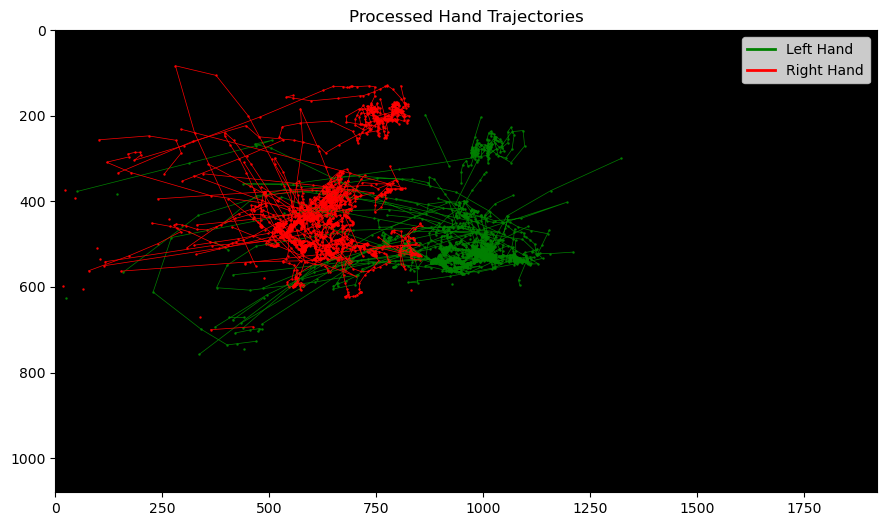

In [ ]:
df_hand_left = df_processed[df_processed['hand_label'] == 'Left']
df_hand_right = df_processed[df_processed['hand_label'] == 'Right']
draw_hands(df_hand_left, df_hand_right, title="Processed Hand Trajectories")

In [9]:
draw_hand_trajectories(video_path, df_processed=df_processed, fps=10, tail_length=30)

Annotating video: data/videos/Study1_Videos/2024-01-15_13-37-36.mp4


Processing Frames: 100%|█████████▉| 8663/8666 [02:51<00:00, 50.53frames/s]

✅ Saved annotated video: data/experiments/2024-01-15_13-37-36_annotated_path_10fps.mp4


'data/experiments/2024-01-15_13-37-36_annotated_path_10fps.mp4'

In [8]:
compare_trajectories(video_path, df_30_fps=None, df_10_fps=df_processed, tail_length=30)

Starting comparison annotation for video: data/videos/Study1_Videos/2024-01-15_13-37-36.mp4


Processing Frames: 100%|█████████▉| 8663/8666 [04:04<00:00, 35.48frames/s]


'data/experiments/2024-01-15_13-37-36_comparison.mp4'